# Ejercicio 1
Implemente un perceptrón simple que aprenda la función lógica AND y la función
lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el
entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos
los vectores de entrada de la red.

In [45]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=100):
        self.weights = np.zeros(input_size + 1)  # +1 para el bias
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors = []

    def predict(self, X):
        h = np.dot(X, self.weights[1:]) + self.weights[0]  # w0 es el bias
        return np.where(h >= 0, 1, -1)

    def train(self, X, y):
        for _ in range(self.epochs):
            E = 0
            for xi, target in zip(X, y):
                y_pred = self.predict(xi)
                error = target - y_pred
                self.weights[1:] += self.learning_rate * error * xi
                self.weights[0] += self.learning_rate * error  # Ajuste del bias
                E += error**2
            self.errors.append(E)
            if E == 0:  # Si no hay errores, detener el entrenamiento
                break
           
    def plot_decision_boundary(self, X, y):
        # Definir los valores de x1
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        x1_vals = np.linspace(x1_min, x1_max, 100)

        # Ecuación de la recta: w0 + w1 * x1 + w2 * x2 = 0 => x2 = -(w0 + w1 * x1) / w2
        x2_vals = -(self.weights[0] + self.weights[1] * x1_vals) / self.weights[2]

        # Gráfico de los puntos y la recta
        plt.plot(x1_vals, x2_vals, 'b-', label='Recta discriminadora')
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', marker='o', label='Clase 1')
        plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='g', marker='x', label='Clase -1')

        plt.xlim([x1_min, x1_max])
        plt.ylim([x2_min, x2_max])
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.legend()
        plt.title('Recta discriminadora y puntos')
        plt.grid(True)
        plt.show()

    # Grafico la evolución del error
    def plot_error(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.errors)
        plt.xlabel('Época')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el entrenamiento')
        plt.grid(True)
        plt.show()

### Caso compuerta AND

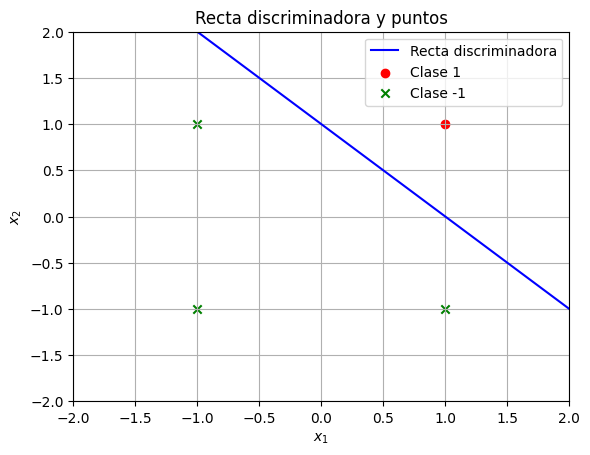

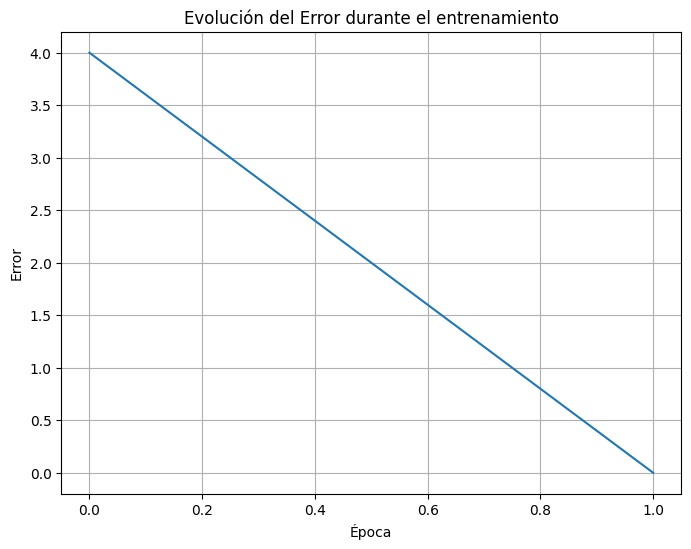

In [46]:
# Datos para la función AND
X_and = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

# Entrenar para la función AND
perceptron_and = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_and.train(X_and, y_and)
perceptron_and.plot_decision_boundary(X_and, y_and)
perceptron_and.plot_error()

### Caso compuerta OR

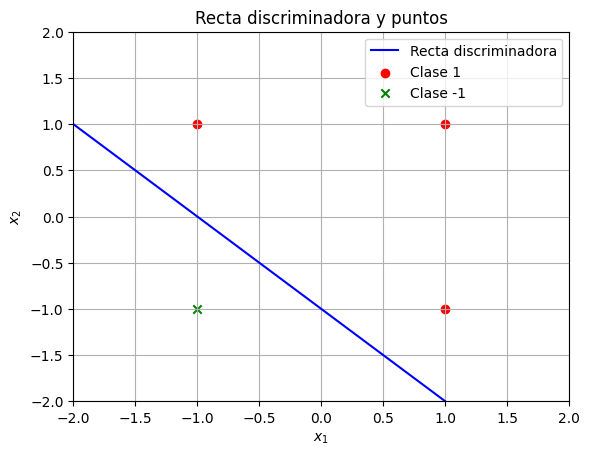

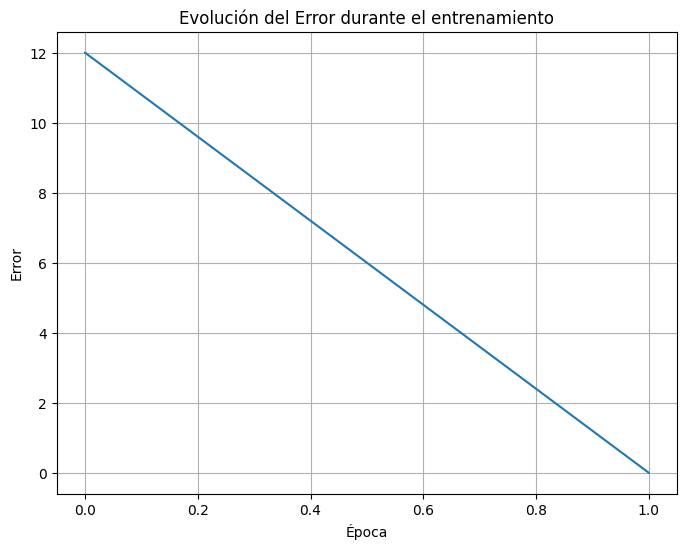

In [47]:
# Datos para la función OR
X_or = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_or = np.array([-1, 1, 1, 1])

# Entrenar para la función OR
perceptron_or = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_or.train(X_or, y_or)
perceptron_or.plot_decision_boundary(X_or, y_or)
perceptron_or.plot_error()

-------------------------------------------------------------------------
# Ejercicio 2

Determine numéricamente cómo varía la capacidad del perceptrón simple en función
del número de patrones enseñados.

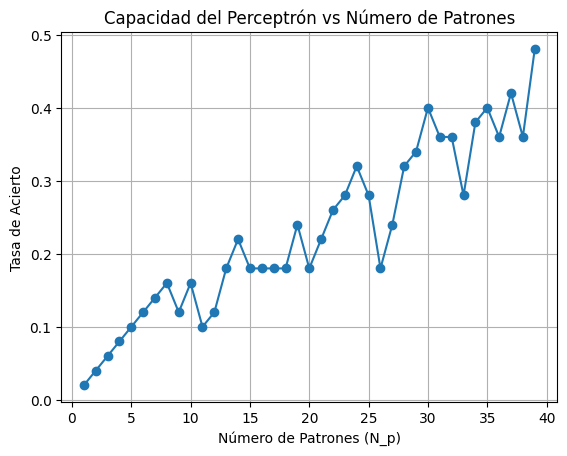

In [48]:
import numpy as np
import matplotlib.pyplot as plt


def generate_patterns(N, N_p):
    """
    Genera patrones de entrada aleatorios y etiquetas.
    N: Número de entradas (dimensiones).
    N_p: Número de patrones.
    """
    X = np.random.uniform(-1, 1, (N_p, N))
    y = np.random.choice([-1, 1], size=N_p)
    
    return X, y

def evaluate_perceptron(N, N_p_values, N_tot=100):
    """
    Evalúa el desempeño del perceptrón para distintos números de patrones N_p.
    N: Número de entradas.
    N_p_values: Lista con los diferentes números de patrones a probar.
    trials: Cantidad de veces que se repite el experimento para cada N_p.
    """
    success_rates = []

    for N_p in N_p_values:
        successes = 0
        for _ in range(N_tot):
            # Generar patrones aleatorios
            X, y = generate_patterns(N, N_p)
            # Crear y entrenar el perceptrón
            perceptron = Perceptron(input_size=N)
            perceptron.train(X, y)
            # Evaluar si clasifica correctamente
            y_pred = perceptron.predict(X)
            successes = np.sum((y-y_pred) == 0)  # Tasa de aciertos
        success_rate = successes / N_tot
        success_rates.append(success_rate)

    return success_rates

# Parámetros
N = 2  # Número de entradas
N_p_values = np.arange(1, 40)  # Número de patrones, de 1 a 40
trials = 50  # Número de pruebas para cada cantidad de patrones

# Evaluar
success_rates = evaluate_perceptron(N, N_p_values, trials)

# Graficar los resultados
plt.plot(N_p_values, success_rates, marker='o')
plt.xlabel('Número de Patrones (N_p)')
plt.ylabel('Tasa de Acierto')
plt.title('Capacidad del Perceptrón vs Número de Patrones')
plt.grid(True)
plt.show()


-------------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 3

Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4
entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre
cómo evoluciona el error durante el entrenamiento.


### Representacion Matricial de la Red (XOR: 2 entradas)
Muestro como se realizaran las cuentas matriciales para un perceptron multicapa de 2 entradas + sesgo, 3 neuronas en capa oculta y 1 neurona de salida


#### Capa de Entrada
La capa de entrada tendra 2 entradas y como se entrenara con 4 patrones, la matriz de entrada sera de $\textbf{3x4}$, la primera fila son 1s que representaran el sesgo, siendo asi la matriz de entrada $\textbf{X}$ :
$$ X =  
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
$$
Cada columna es un patrón y cada fila es la entrada a cada entrada de la capa de entrada. 


#### Capa Oculta
Para el caso de la XOR de 2 entradas, el caso minimo con el que se logra aprenderla es con 3 neuronas de capa oculta. Supongamos 3 neuronas de capa oculta (filas), entonces la matriz de
pesos sinapticos entre la capa de entrada y la capa oculta es $W_{input} \in \mathbb{R}^{3 \times 2}$
$$
W_{input} =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
$$
Donde $w_{j0}$ corresponde al peso sinaptico del sesgo de la neurona j


#### Capa Salida 
Dado que se tiene una sola salida y la capa oculta solo tiene 3 neuronas, la matriz de pesos sinapticos entre la capa oculta y la capa de salida es $W_{output} \in \mathbb{R}^{1 \times 3}$ :
$$
W_{output} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
$$



### Fordward Propagation
Partimos desde la capa de entrada, obtengo que la entrada neta a la capa oculta es:

$$
H_{input} = W_{input} * X =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
*
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} & h_{14} \\
h_{21} & h_{22} & h_{23} & h_{24} \\
h_{31} & h_{32} & h_{33} & h_{34}
\end{bmatrix}

$$

Luego, pasando por la funcion de activación $\textbf{g(x)}$ obtengo que: 
$$X_{input} = g(H_{input}) = \begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}$$

Luego se parte de la entrada neta a la capa de salida :
$$
H_{output} = W_{output} * X_{input} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
*
\begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}
=
\begin{bmatrix}
h_{1} & h_{2} & h_{3} & h_{4} \\
\end{bmatrix}
$$


Finalmente la salida $y$ es:
$$
y = g(H_{output}) = \begin{bmatrix}
y_{1} & y_{2} & y_{3} & y_{4} \\
\end{bmatrix}
$$

### Backward Propagation
El primer delta a calcular es :
$$
\begin{align*}
\delta_{output} = g'(H_{output}) \cdot (y_d - y) & = \begin{bmatrix}
g'(h_{1}) & g'(h_{2}) & g'(h_{3}) & g'(h_{4}) \\
\end{bmatrix}
\cdot
\begin{bmatrix}
y_d(1) - y_{1} & y_d(2) - y_{2} & y_d(3) - y_{3} & y_d(4) - y_{4} \\
\end{bmatrix} \\
& =
\begin{bmatrix}
g'(h_{1})(y_d(1) - y_{1}) & g'(h_{2})(y_d(2) - y_{2}) & g'(h_{3})(y_d(3) - y_{3}) & g'(h_{4})(y_d(4) - y_{4}) \\
\end{bmatrix}
\end{align*}
$$

Luego:
$$
\delta_{hidden} = g'(H_{input}) \cdot (W_{output} * \delta_{output}^T)
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MultiLayerPerceptron:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5, epochs=10000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        
        # Inicialización de pesos y sesgos
        self.weights_input_hidden = np.random.randn(hidden_size, input_size + 1) * 0.1  # Inicialización aleatoria pequeña
        self.weights_hidden_output = np.random.randn(output_size, hidden_size) * 0.1  # Inicialización aleatoria pequeña


    def activation(self, x):
        """Función de activación (sigmoide)."""
        return 1 / (1 + np.exp(-x))

    def activation_derivative(self, x):
        """Derivada de la función de activación (sigmoide)."""
        sig = self.activation(x)
        return sig * (1 - sig)
    
    def train(self, X, y):
        errors = []
        ones_row = np.ones((1, X.shape[1]))  # Crear una fila de unos con el mismo número de columnas que A
        X = np.vstack([ones_row, X])
        for _ in range(self.epochs):
            # Propagación hacia adelante
            hidden_layer_input = self.weights_input_hidden @ X
            hidden_layer_output = self.activation(hidden_layer_input)
            output_layer_input = self.weights_hidden_output @ hidden_layer_output
            output = self.activation(output_layer_input)
            
            # Cálculo del error
            error = y - output
            errors.append(1/2 *np.sum((error)**2))
            
            # Backpropagation
            delta_output =  self.activation_derivative(output_layer_input) * error 
            delta_hidden =  self.activation_derivative(hidden_layer_input) * (self.weights_hidden_output.T @ delta_output) 
            
            # Actualización de pesos y sesgos
            self.weights_hidden_output += self.learning_rate * (delta_output @ hidden_layer_output.T)
            self.weights_input_hidden += self.learning_rate * (delta_hidden @ X.T)

        return errors
    
    def predict(self, X):
        ones_row = np.ones((1, X.shape[1]))  # Crear una fila de unos con el mismo número de columnas que A
        X = np.vstack([ones_row, X])
        hidden_layer_input = self.weights_input_hidden @ X
        hidden_layer_output = self.activation(hidden_layer_input)
        output_layer_input = self.weights_hidden_output @ hidden_layer_output
        
        return self.activation(output_layer_input)


## XOR de 2 entradas

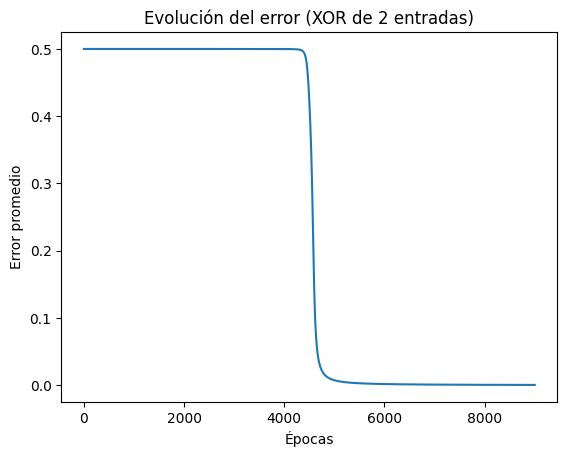

XOR de 2 entrada
Entrada: [0 0] -> Salida predicha: 0.01232049746251562
Entrada: [0 1] -> Salida predicha: 0.986485708065591
Entrada: [1 0] -> Salida predicha: 0.981162177758677
Entrada: [1 1] -> Salida predicha: 0.017102068838940575


In [80]:
# Datos de entrenamiento para XOR de 2 entradas
# Definir las columnas de la función XOR
col1 = np.array([0, 0])
col2 = np.array([0, 1])
col3 = np.array([1, 0])
col4 = np.array([1, 1])

# Apilar las columnas para formar la matriz 2x4
X_2 = np.column_stack((col1, col2, col3, col4))
y_2 = np.array([[0, 1, 1, 0]])

# Inicialización y entrenamiento del perceptrón multicapa
mlp = MultiLayerPerceptron(input_size=2, hidden_size=3, output_size=1, learning_rate=1.2, epochs=9000)
errors_2 = mlp.train(X_2, y_2)

# Visualización de la evolución del error
plt.plot(errors_2)
plt.title('Evolución del error (XOR de 2 entradas)')
plt.xlabel('Épocas')
plt.ylabel('Error promedio')
plt.show()
prediction = mlp.predict(X_2)
# Predicción para verificar los resultados

print("XOR de 2 entrada")
print(f"Entrada: {X_2[:,0].T} -> Salida predicha: {prediction[0,0]}")
print(f"Entrada: {X_2[:,1].T} -> Salida predicha: {prediction[0,1]}")
print(f"Entrada: {X_2[:,2].T} -> Salida predicha: {prediction[0,2]}")
print(f"Entrada: {X_2[:,3].T} -> Salida predicha: {prediction[0,3]}")

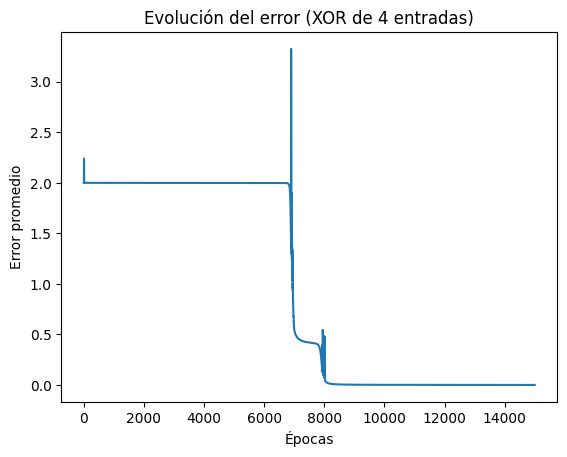

XOR de 4 entradas
Entrada: [0 0 0 0] -> Salida predicha: 0.005736740637503233 y salida correcta : 0
Entrada: [0 0 0 1] -> Salida predicha: 0.9953425964950322 y salida correcta : 1
Entrada: [0 0 1 0] -> Salida predicha: 0.9948540952774788 y salida correcta : 1
Entrada: [0 0 1 1] -> Salida predicha: 0.0065587875393753135 y salida correcta : 0
Entrada: [0 1 0 0] -> Salida predicha: 0.995310368726163 y salida correcta : 1
Entrada: [0 1 0 1] -> Salida predicha: 0.006568163599014518 y salida correcta : 0
Entrada: [0 1 1 0] -> Salida predicha: 0.006560459641283273 y salida correcta : 0
Entrada: [0 1 1 1] -> Salida predicha: 0.9894278419495035 y salida correcta : 1
Entrada: [1 0 0 0] -> Salida predicha: 0.9945829880367542 y salida correcta : 1
Entrada: [1 0 0 1] -> Salida predicha: 0.004745142094109013 y salida correcta : 0
Entrada: [1 0 1 0] -> Salida predicha: 0.004962497155363979 y salida correcta : 0
Entrada: [1 0 1 1] -> Salida predicha: 0.9927439323380096 y salida correcta : 1
Entrada: [

In [81]:
# Datos de entrenamiento para XOR de 4 entradas
# Definir todas las combinaciones posibles de 4 entradas binarias
X_4 = np.array([[0, 0, 0, 0],
                [0, 0, 0, 1],
                [0, 0, 1, 0],
                [0, 0, 1, 1],
                [0, 1, 0, 0],
                [0, 1, 0, 1],
                [0, 1, 1, 0],
                [0, 1, 1, 1],
                [1, 0, 0, 0],
                [1, 0, 0, 1],
                [1, 0, 1, 0],
                [1, 0, 1, 1],
                [1, 1, 0, 0],
                [1, 1, 0, 1],
                [1, 1, 1, 0],
                [1, 1, 1, 1]]).T  # Transponer para que las columnas sean las entradas

# Salidas correspondientes para la función XOR de 4 entradas
# La salida será 1 solo si hay un número impar de 1s en la entrada
y_4 = np.array([[0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0]])

# Inicialización y entrenamiento del perceptrón multicapa
mlp = MultiLayerPerceptron(input_size=4, hidden_size=6, output_size=1, learning_rate=1.9, epochs=15000)
errors_4 = mlp.train(X_4, y_4)

# Visualización de la evolución del error
plt.plot(errors_4)
plt.title('Evolución del error (XOR de 4 entradas)')
plt.xlabel('Épocas')
plt.ylabel('Error promedio')
plt.show()

# Predicción para verificar los resultados
prediction = mlp.predict(X_4)
print("XOR de 4 entradas")
for i in range(X_4.shape[1]):
    print(f"Entrada: {X_4[:,i].T} -> Salida predicha: {prediction[0, i]} y salida correcta : {y_4[0,i]}")
